# Data and Results
***

**Author:** *Chus Casado Rodríguez*<br>
**Date:** *13-07-2026*<br>

**Introduction:**<br>

This notebook analyses the results of the calibration of process-based reservoir routines on the ResOpsUS dataset.

The plots produced here will be used in the sections Data and Results of the paper.

In [1]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path

import yaml
import pickle

from reservoirs_lshm import Config, read_attributes, read_timeseries
from reservoirs_lshm.utils.plots import boxplot_parameters, swarmplot_comparison
from reservoirs_lshm.utils.utils import return_period
from reservoirs_lshm.utils.maps import map_reservoirs, map_reservoir_use

import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams.update({
#     "font.family": 'Arial',
    "font.size": 12,       # Default font size for text
#     "axes.titlesize": 16,  # Title font size
#     "axes.labelsize": 12,  # X and Y label font size
#     "xtick.labelsize": 13, # X tick font size
#     "ytick.labelsize": 12, # Y tick font size
#     "legend.fontsize": 12  # Legend font size
})

## Configuration

In [3]:
path = Path('/home/casadoj/Data/reservoirs')
cfg = Config(path / 'ResOpsUS/v2.1/results_before_GRanD_correction/mhm/mhm_storage.yml')

PATH_RESULTS = cfg.PATH_DEF.parent.parent
PATH_PLOTS = PATH_RESULTS / 'figures'
PATH_PLOTS.mkdir(parents=False, exist_ok=True)
print(f'Results will be saved in {PATH_PLOTS}')

models = {
    'lisflood': 'LISFLOOD',
    'camaflood': 'CaMa-Flood',
    'mhm': 'mHM',
    'starfit': 'Starfit'
}

runs = {
    'default': 'default',
    'OBJ-Q': 'calibration/univariate/outflow',
    'OBJ-V': 'calibration/univariate/storage',
    'OBJ-QV': 'calibration/bivariate'
}

Results will be saved in /home/casadoj/Data/reservoirs/ResOpsUS/v2.1/results_before_GRanD_correction/figures


## Data

### Base layers

In [4]:
# load GloFAS' elevation and upstream area map
elevation = rxr.open_rasterio(cfg.PATH_DATA.parent / 'GIS' / 'elv_3min_US.tif', masked=True).squeeze('band')
uparea = rxr.open_rasterio(cfg.PATH_DATA.parent / 'GIS' / 'upArea_3min_US.tif', masked=True).squeeze('band')

### Reservoirs

In [5]:
# load reservoirs
reservoirs = gpd.read_file(cfg.PATH_DATA.parent / 'GIS' / 'reservoirs_677_3sec.shp').set_index('ID')
reservoirs.index.name = 'GRAND_ID'

print(f'{len(reservoirs)} reservoirs in the original ResOpsUS dataset')

677 reservoirs in the original ResOpsUS dataset


### Attributes

In [6]:
# list of reservoirs to be trained
reservoir_list = pd.read_csv(cfg.RESERVOIRS_FILE, header=None).squeeze().tolist()

# import all tables of attributes
attributes = read_attributes(cfg.PATH_DATA / 'attributes', reservoir_list)

# invert the one-hot encoder of main reservoir use
col_use = attributes.columns[attributes.columns.str.contains('MAIN_')]
col_use = [col for col in col_use if 'BASIN' not in col]
main_use = attributes[col_use].idxmax(axis=1)
attributes['MAIN_USE'] = main_use.replace({col: col.split('_')[-1] for col in col_use})
attributes.drop(col_use, axis=1, inplace=True)

# select items in reservoirs
reservoirs = reservoirs.loc[reservoirs.index.intersection(attributes.index)]

print(f'{len(attributes)} reservoirs in the attributes table')
print(f'{len(reservoirs)} reservoirs in the shape file')

164 reservoirs in the attributes table
164 reservoirs in the shape file


Create shapefile of the reservoirs selected for the model comparison.

```Python
import geopandas as gpd

# convert to GeoPandas
attributes = gpd.GeoDataFrame(
    attributes,
    geometry=gpd.points_from_xy(attributes.LON_LISFLOOD, attributes.LAT_LISFLOOD),
    crs='epsg:4326'
)

# export shapefile
attributes.to_file(cfg.PATH_DATA / 'selection' / 'reservoirs.shp')
```

### Time series

In [7]:
# training periods
with open(cfg.PERIODS_FILE, 'rb') as file:
    periods = pickle.load(file)
# periods = {str(ID): {f'{x}_dates': [date] for x, date in dct.items()} for ID, dct in periods.items()}

# read time series
inputs = [var for var in [cfg.INFLOW, cfg.PRECIPITATION, cfg.EVAPORATION, cfg.DEMAND] if var]
outputs = ['storage', 'outflow']
timeseries = read_timeseries(
    path=cfg.PATH_DATA / 'time_series' / 'csv',
    reservoirs=attributes.index,
    periods=periods,
    variables=inputs + outputs
)
print(f'{len(timeseries)} reservoirs in the time series')

# compute 100-year return period of the inflow
Q100 = [return_period(ts.inflow, T=100) for grand_id, ts in timeseries.items()]
Q100 = xr.DataArray(data=Q100, coords=[list(timeseries)], dims=['ID'])

  0%|          | 0/164 [00:00<?, ?it/s]

164 reservoirs in the time series


## Load results

In [8]:
parameters = {}
performance = []
for model in tqdm(models, desc='reservoir model'):

    pars_model = []
    perf_model = []
    for run, subpath in runs.items():

        path = PATH_RESULTS / model / subpath

        # load parameters
        try:
            pars_run = []
            for file in path.glob('*_parameters.yml'):
                grand_id = int(file.stem.split('_')[0])
                if grand_id not in attributes.index:
                    continue
                with open(file, 'r') as f:
                     dct = yaml.load(f, Loader=yaml.FullLoader)
                ds = xr.Dataset({key: xr.DataArray(value) for key, value in dct.items()})
                ds = ds.assign_coords(ID=[grand_id], run=[run])
                pars_run.append(ds)
            pars_model.append(xr.concat(pars_run, dim='ID'))
        except Exception as e:
            print(f'Error while reading parameters from model {model} and run {run}:\n{e}')          

        # load performance
        try:
            perf_run = []
            for file in (path).glob('*_performance.csv'):
                grand_id = int(file.stem.split('_')[0])
                if grand_id not in attributes.index:
                    continue
                ds = xr.Dataset.from_dataframe(pd.read_csv(file, index_col='metric'))
                ds = ds.assign_coords(model=[model], run=[run], ID=[grand_id])
                perf_run.append(ds)
            perf_model.append(xr.concat(perf_run, dim='ID'))
        except Exception as e:
            print(f'Error while reading performance from model {model} and run {run}:\n{e}')  
    
    try:
        parameters[model] = xr.concat(pars_model, dim='run')
    except:
        pass
    
    try:
        performance.append(xr.concat(perf_model, dim='run'))
    except:
        pass

performance = xr.concat(performance, dim='model')

# rename model 'hanazaki' as 'camaflood'
performance = performance.assign_coords(
    model=[m if 'hanazaki' not in m else 'camaflood' for m in performance.model.values]
)
performance = performance.assign_coords(model=[models[model] for model in performance.model.values])

reservoir model:   0%|          | 0/4 [00:00<?, ?it/s]

Error while reading parameters from model starfit and run default:
must supply at least one object to concatenate
Error while reading performance from model starfit and run default:
must supply at least one object to concatenate
Error while reading parameters from model starfit and run OBJ-Q:
must supply at least one object to concatenate
Error while reading performance from model starfit and run OBJ-Q:
must supply at least one object to concatenate
Error while reading parameters from model starfit and run OBJ-V:
must supply at least one object to concatenate
Error while reading performance from model starfit and run OBJ-V:
must supply at least one object to concatenate
Error while reading parameters from model starfit and run OBJ-QV:
must supply at least one object to concatenate


## Figures
### Reservoirs

Map of the reservoirs included in the study. This will be Figure 1 in the section Data of the paper.

#### Area & Capacity

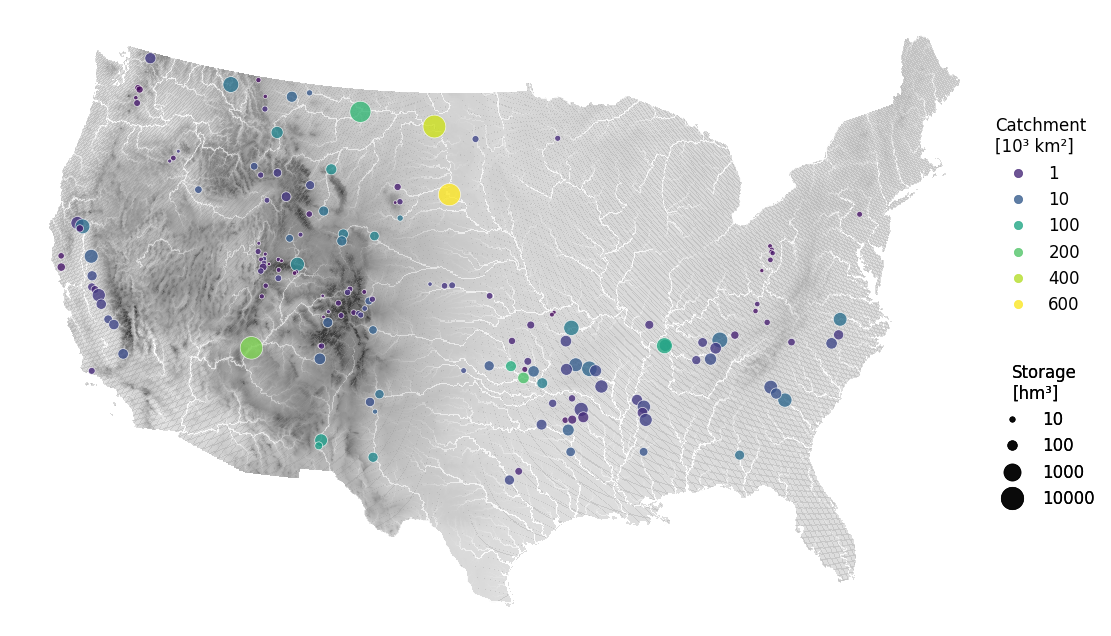

In [9]:
epsg = '9311'
map_reservoirs(
    reservoirs.geometry, 
    attributes.CAP_MCM, 
    attributes.CATCH_SKM, 
    elevation, 
    uparea, 
    proj=f'epsg:{epsg}', 
    extent=[-122, -74, 25, 50],
    # save=PATH_PLOTS / f'map_reservoirs_epsg{epsg}.pdf'
    )

#### Use & Regulation

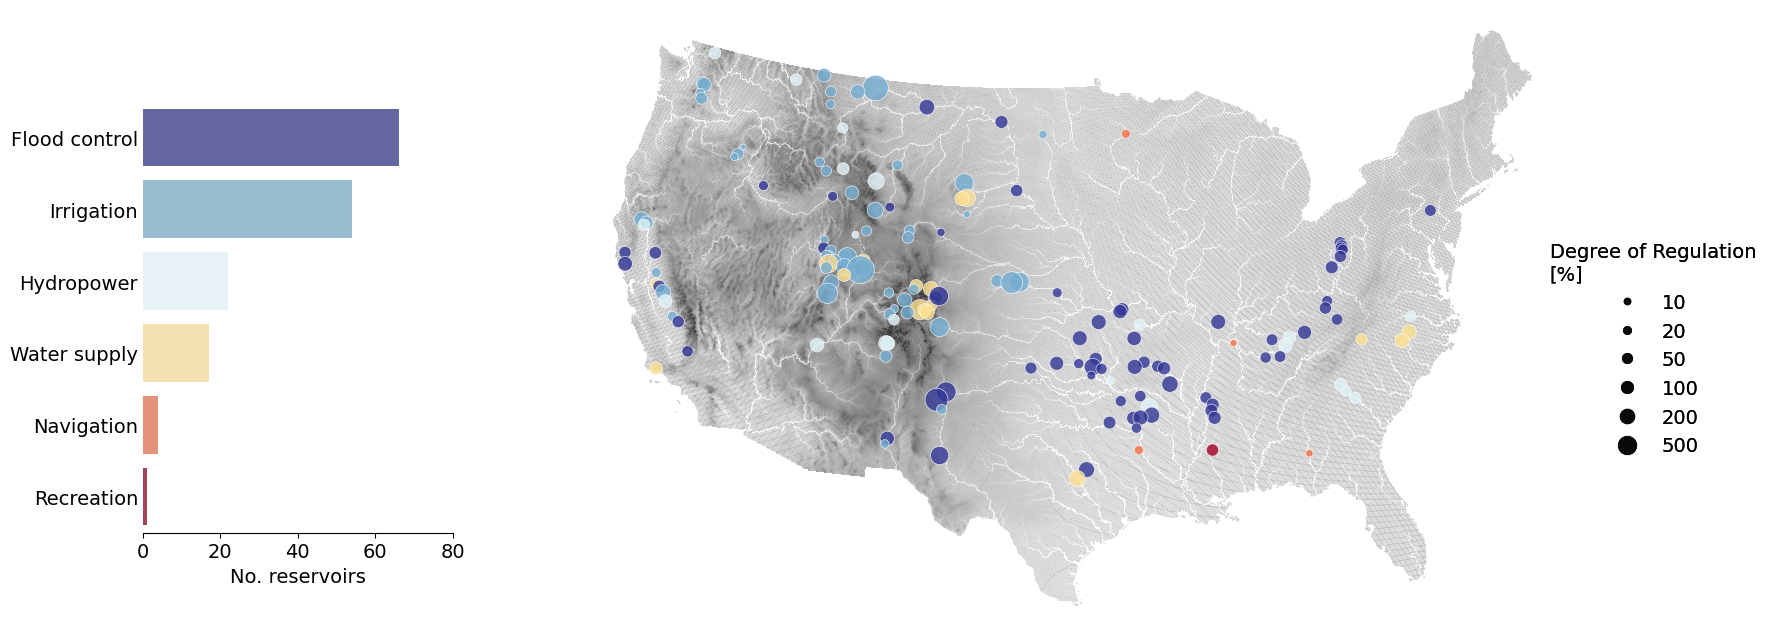

In [12]:
plt.rcParams.update({'font.size': 14})
epsg = '9311'

map_reservoir_use(
    reservoirs.geometry,
    attributes['MAIN_USE'],
    attributes['DOR_PC'],
    elevation,
    uparea,
    proj=f'epsg:{epsg}', 
    extent=[-120, -75, 25, 50],
    cmap='RdYlBu_r',
    xlim=(0, 80),
    save=PATH_PLOTS / f'map_reservoirs_use_epsg{epsg}.pdf'
)

### Performance

#### Compare simulations

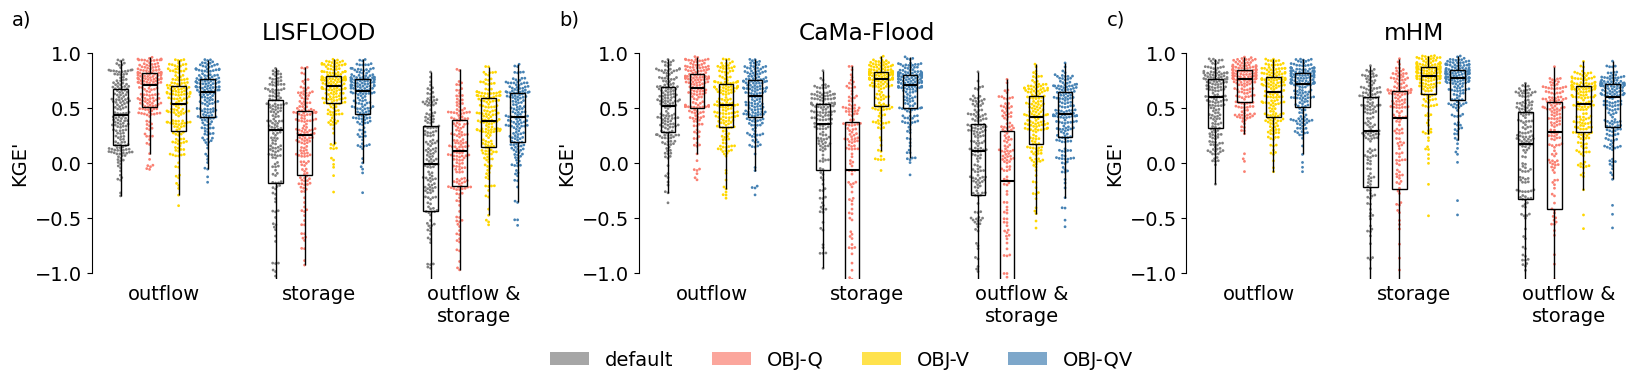

In [ ]:
plt.rcParams.update({'font.size': 14})

# compare runs
swarmplot_comparison(
    performance.sel(model=['LISFLOOD', 'CaMa-Flood', 'mHM'], run=['default', 'OBJ-Q', 'OBJ-V', 'OBJ-QV']),
    ax_dim='model',
    col_dim='run',
    kind='swarm',
    size=2,
    ylabel="KGE'",
    width_ratio=.8,
    save=PATH_PLOTS / f'swarmplots_compare_variables.pdf'
)

#### Compare models

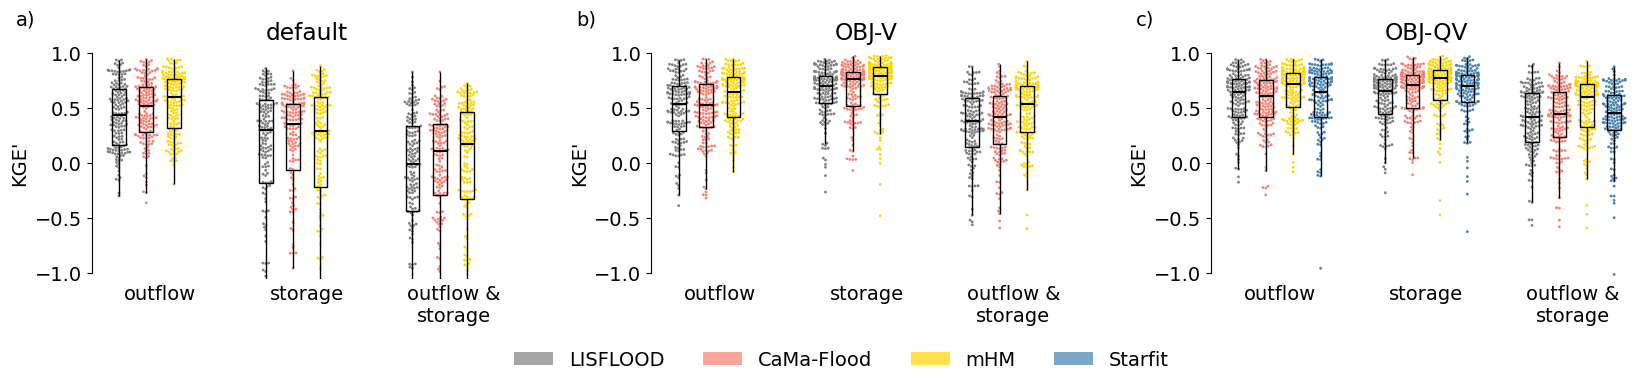

In [23]:
plt.rcParams.update({'font.size': 14})

# compare models
swarmplot_comparison(
    performance.sel(model=['LISFLOOD', 'CaMa-Flood', 'mHM', 'Starfit'], run=['default', 'OBJ-V', 'OBJ-QV']),
    ax_dim='run',
    col_dim='model',
    kind='swarm',
    size=2,
    ylabel="KGE'",
    width_ratio=.8,
    save=PATH_PLOTS / f'swarmplots_compare_models.pdf'
)

### Parameters

#### Linear

In [28]:
model = 'linear'
parameter_range = {'T': [7, 2190]}

if model in models:

    pars_model = parameters[model][list(parameter_range)]

    # boxplot comparing parameterizations across calibration runs
    boxplot_parameters(pars_model, parameter_range)#, save=PATH_PLOTS / model / 'parameters_boxplot.jpg')

    # pairplot comparing parameters
    if len(pars_model) > 1:
        pairplot = sns.pairplot(
            data=pars_model.to_dataframe().reset_index(),
            vars=list(parameter_range),
            hue='run',
            # palette='magma',
            corner=True,
            dropna=True,
            plot_kws={'alpha': 0.666, 's': 10},
        );
        plt.savefig(PATH_RESULTS / model / 'parameters_pairplot.jpg', dpi=300, bbox_inches='tight')

    # pairplot comparing runs for each parameter
    for parname, da in pars_model.items():
        data = da.to_pandas().transpose()
        pairplot= sns.pairplot(data=data,
                            # diag_kind='hist',
                            # hue='MAIN_USE', 
                            corner=True);
        pmin, pmax = parameter_range[parname]
        pmin -= 2e-2
        pmax += 2e-2
        for ax in pairplot.axes.flatten():
            if ax is None:
                continue
            ax.set(xlim=(pmin, pmax),
                ylim=(pmin, pmax))
        pairplot.fig.suptitle(parname, y=.95);
        plt.savefig(PATH_RESULTS / model / f'parameter_{parname}_pairplot.jpg', dpi=300, bbox_inches='tight')

#### Lisflood

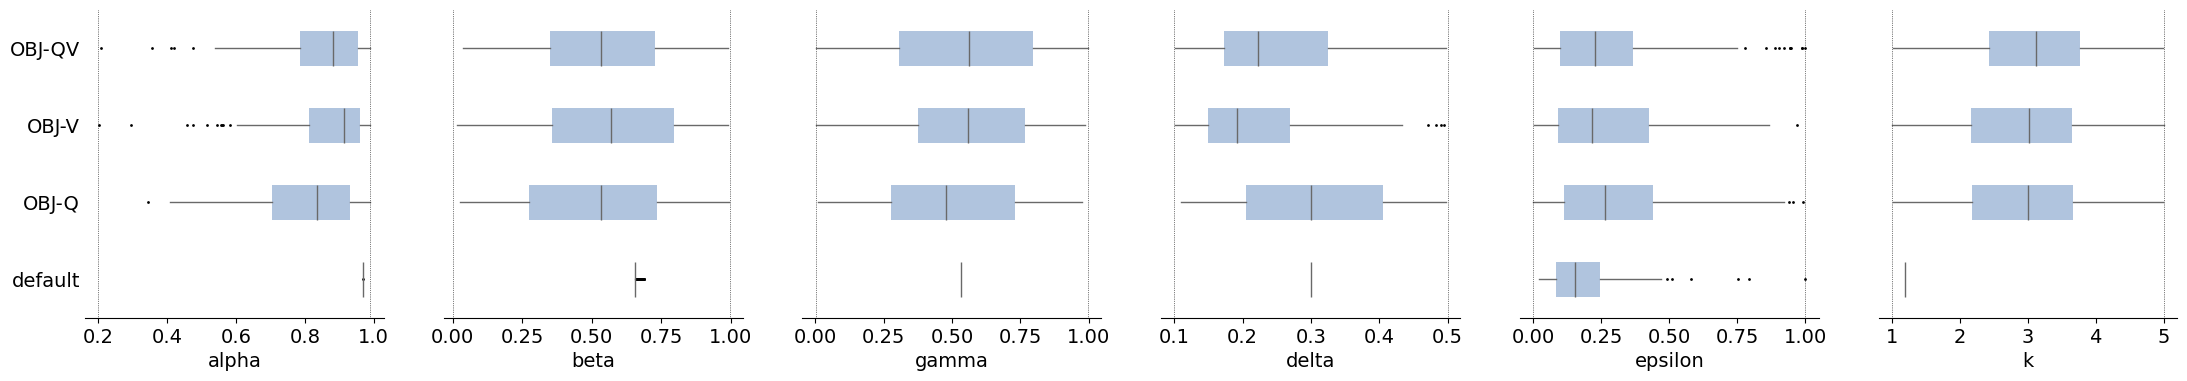

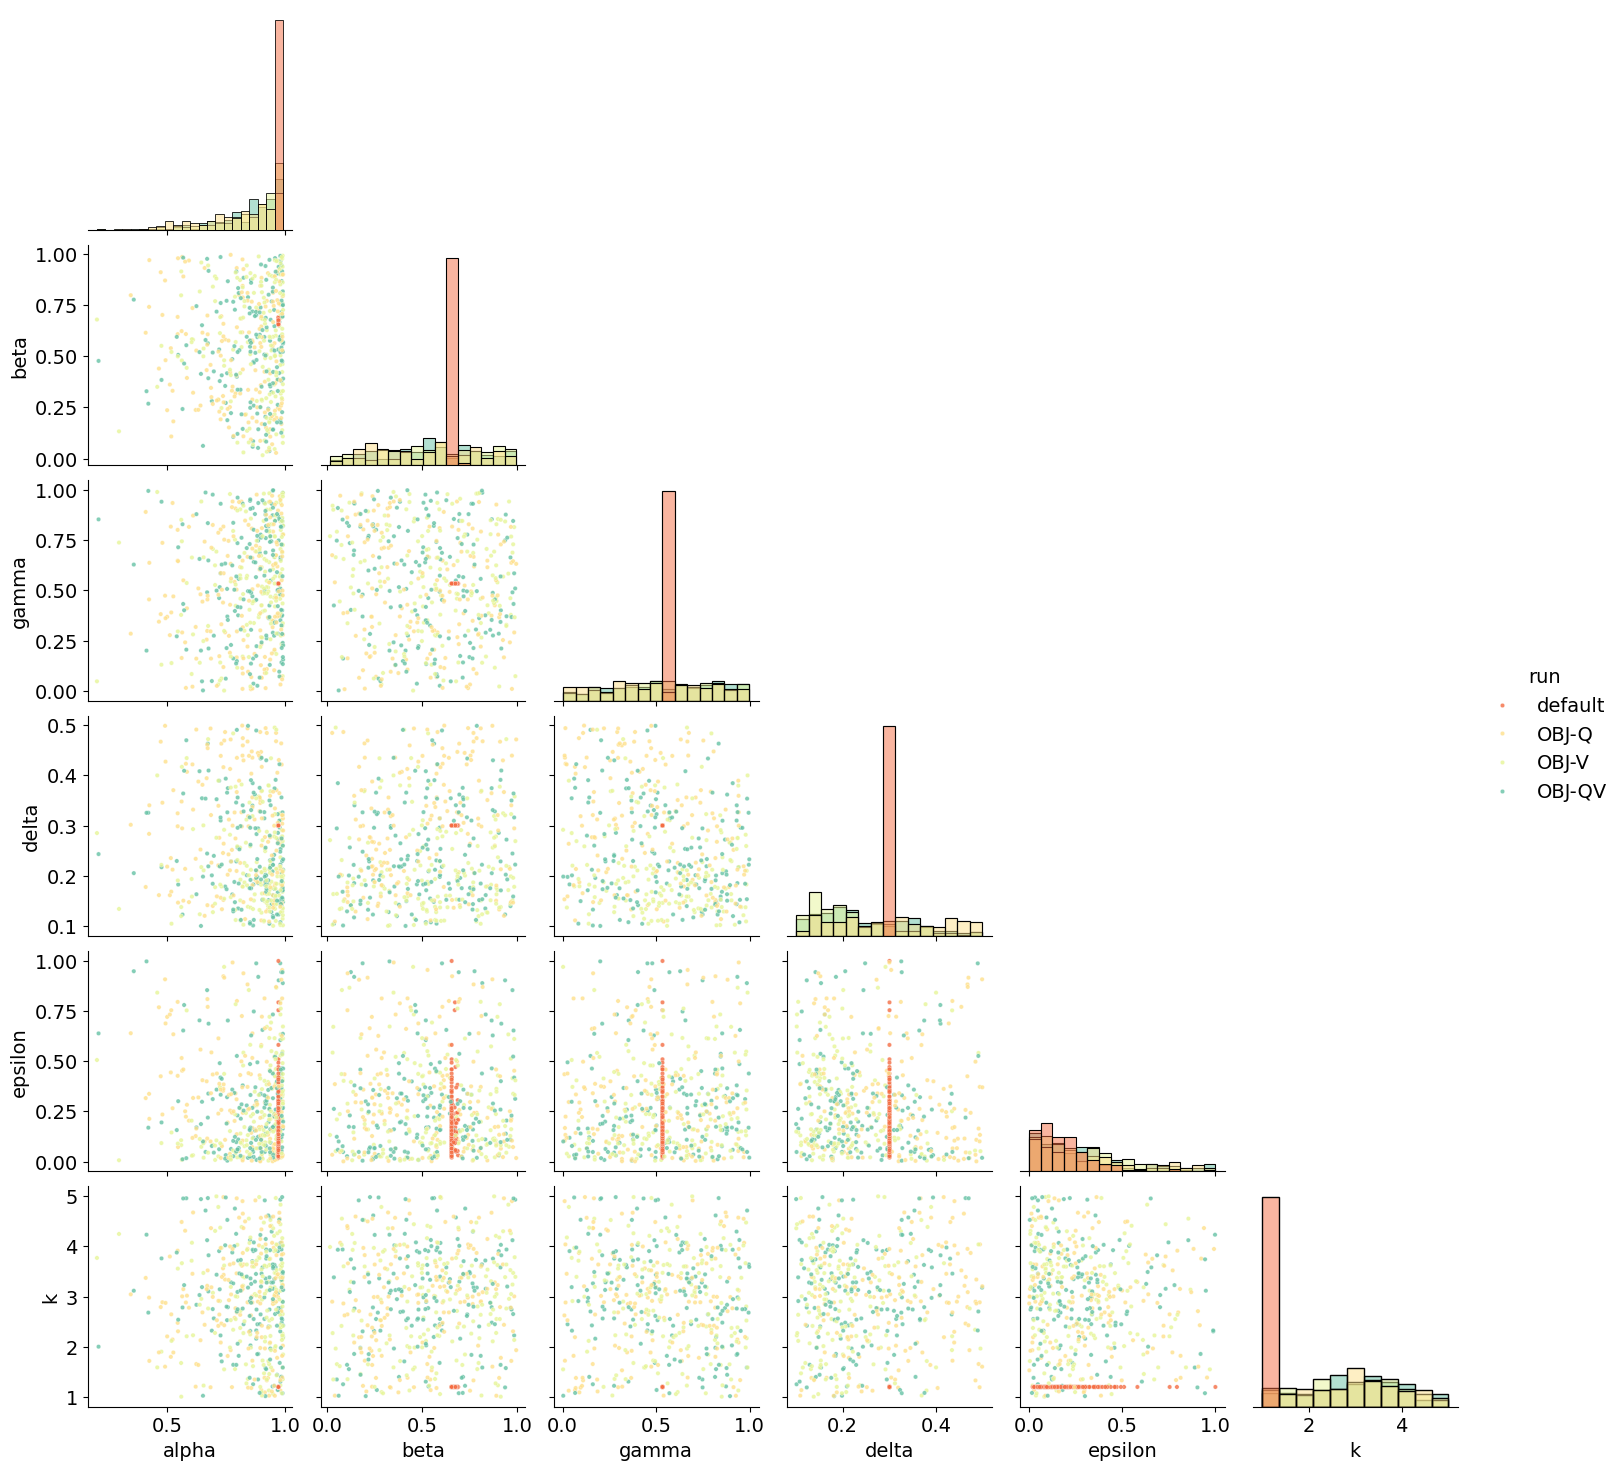

In [ ]:
model = 'lisflood'

parameter_range = {
    'alpha': [0.20, 0.99],
    'beta': [0.001, 0.999],
    'gamma': [0.001, 0.999],
    'delta': [0.1, 0.5],
    'epsilon': [0.001, 0.999],
    'k': [1.0, 5.0]
}

if model in models:
    pars_model = parameters[model]
    pars_model = xr.Dataset({
        'alpha': pars_model['Vf'] / pars_model['Vtot'],
        'beta': (pars_model['Vn'] - pars_model['Vmin']) / (pars_model['Vf'] - pars_model['Vmin']),
        'gamma': (pars_model['Vn_adj'] - pars_model['Vn']) / (pars_model['Vf'] - pars_model['Vn']),
        'delta': pars_model['Qf'] / Q100,
        'epsilon': pars_model['Qn'] / pars_model['Qf'],
        'k': pars_model['k']
    })

    # boxplot comparing parameterizations across calibration runs
    boxplot_parameters(
        pars_model, 
        parameter_range, 
        save=PATH_RESULTS / model / 'parameters_boxplot.jpg'
    )

    # pairplot comparing parameters
    if len(pars_model) > 1:
        pairplot = sns.pairplot(
            data=pars_model.to_dataframe().reset_index(),
            vars=list(parameter_range),
            hue='run',
            palette='Spectral',
            diag_kind='hist',
            corner=True,
            dropna=True,
            plot_kws={'alpha': 0.8, 's': 10},
        );
        plt.savefig(PATH_RESULTS / model / 'parameters_pairplot.jpg', dpi=300, bbox_inches='tight')

    # # pairplot comparing runs for each parameter
    # for parname, da in pars_model.items():
    #     data = da.to_pandas().transpose()
    #     pairplot= sns.pairplot(data=data,
    #                            # diag_kind='hist',
    #                            # hue='MAIN_USE', 
    #                            corner=True);
    #     pmin, pmax = parameter_range[parname]
    #     pmin -= 2e-2
    #     pmax += 2e-2
    #     for ax in pairplot.axes.flatten():
    #         if ax is None:
    #             continue
    #         ax.set(xlim=(pmin, pmax),
    #                ylim=(pmin, pmax))
    #     pairplot.fig.suptitle(parname, y=.95);
    #     plt.savefig(PATH_RESULTS / model / f'parameter_{parname}_pairplot.jpg', dpi=300, bbox_inches='tight')

#### CaMa-Flood

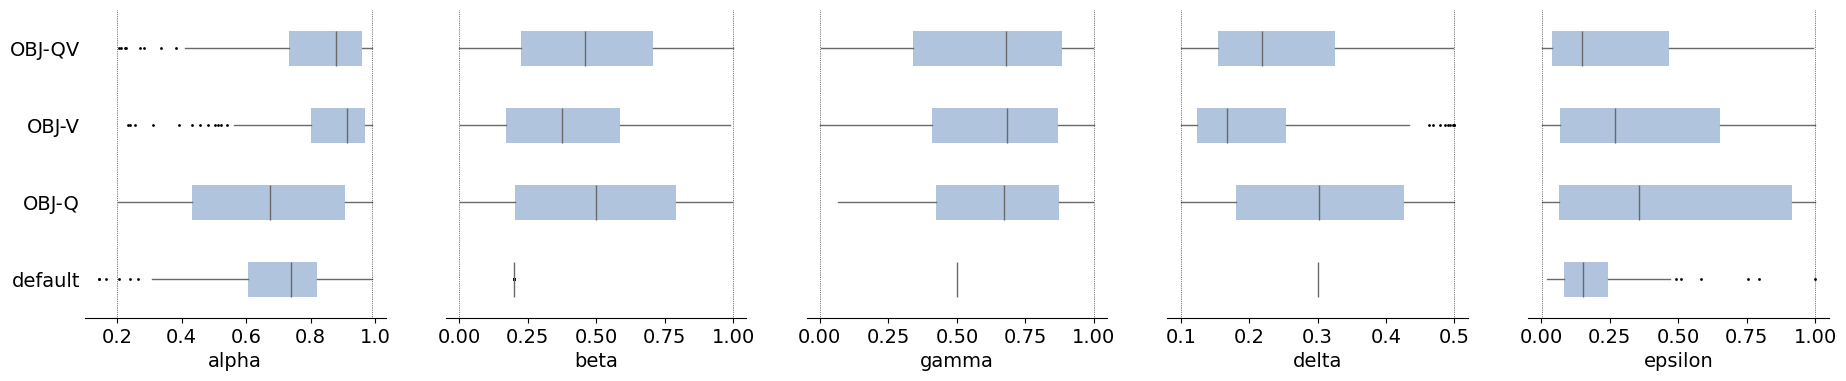

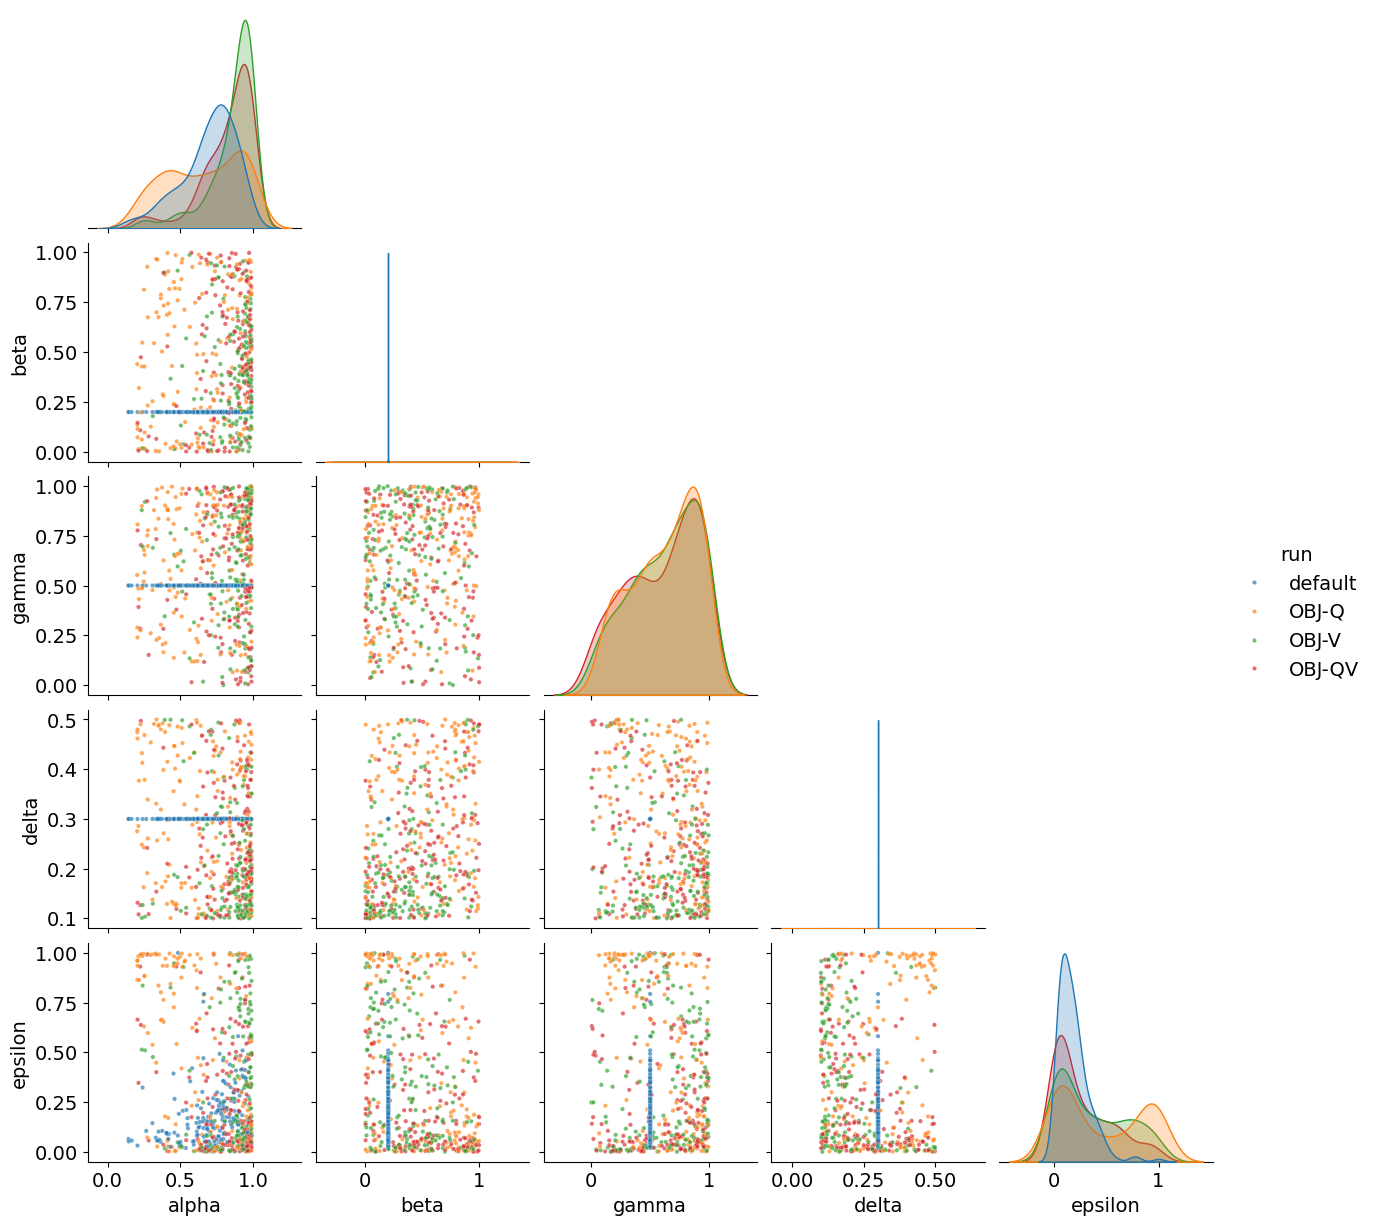

In [31]:
model = 'camaflood'

parameter_range = {
    'alpha': [0.2, 0.99],
    'beta': [0.001, 0.999],    
    'gamma': [0.001, 0.999],
    'delta': [0.1, 0.5],
    'epsilon': [0.001, 0.999]
}

if model in models:

    pars_model = parameters[model]
    pars_model = xr.Dataset({
        'alpha': pars_model['Vf'] / pars_model['Vtot'],
        'beta': (pars_model['Vtot'] - pars_model['Ve']) / (pars_model['Vtot'] - pars_model['Vf']),
        'gamma': pars_model['Vmin'] / pars_model['Vf'],
        'delta': pars_model['Qf'] / Q100,
        'epsilon': pars_model['Qn'] / pars_model['Qf']
    })

    # boxplot comparing parameterizations across calibration runs
    boxplot_parameters(
        pars_model, 
        parameter_range, 
        save=PATH_RESULTS / model / 'parameters_boxplot.jpg'
    )

    # pairplot comparing parameters
    if len(pars_model) > 1:
        pairplot = sns.pairplot(
            data=pars_model.to_dataframe().reset_index(),
            vars=list(parameter_range),
            hue='run',
            # palette='magma',
            corner=True,
            dropna=True,
            plot_kws={'alpha': 0.666, 's': 10},
        );
        plt.savefig(PATH_RESULTS / model / 'parameters_pairplot.jpg', dpi=300, bbox_inches='tight')

    # # pairplot comparing runs for each parameter
    # for parname, da in pars_model.items():
    #     data = da.to_pandas().transpose()
    #     pairplot= sns.pairplot(data=data,
    #                            # diag_kind='hist',
    #                            # hue='MAIN_USE', 
    #                            corner=True);
    #     pmin, pmax = parameter_range[parname]
    #     pmin -= 2e-2
    #     pmax += 2e-2
    #     for ax in pairplot.axes.flatten():
    #         if ax is None:
    #             continue
    #         ax.set(xlim=(pmin, pmax),
    #                ylim=(pmin, pmax))
    #     pairplot.fig.suptitle(parname, y=.95);
    #     plt.savefig(PATH_RESULTS / model / f'parameter_{parname}_pairplot.jpg', dpi=300, bbox_inches='tight')

#### mHM

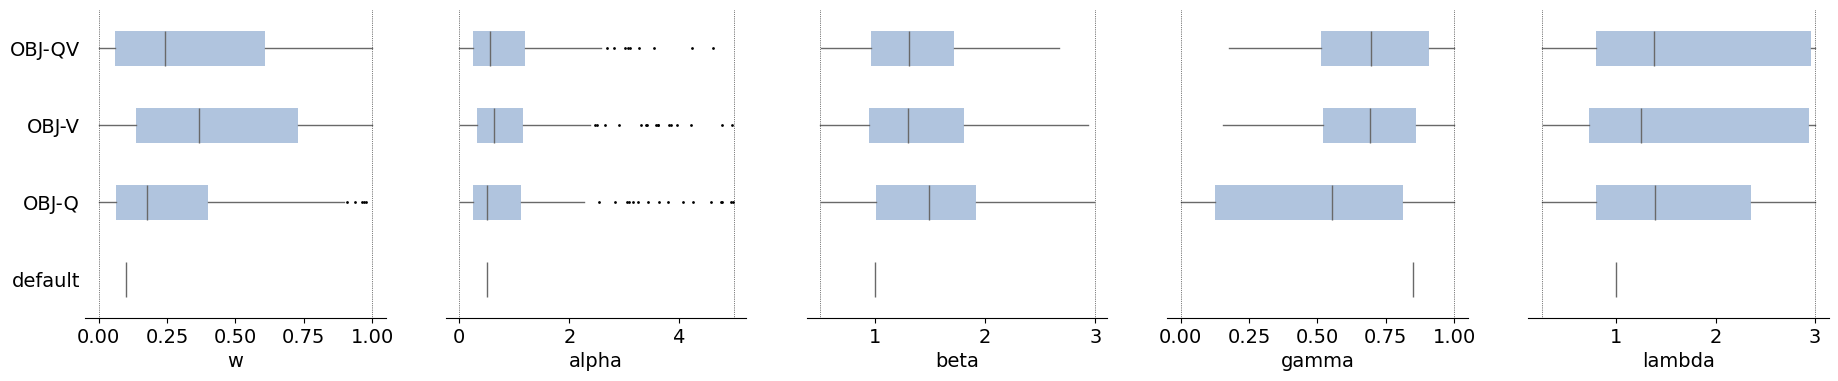

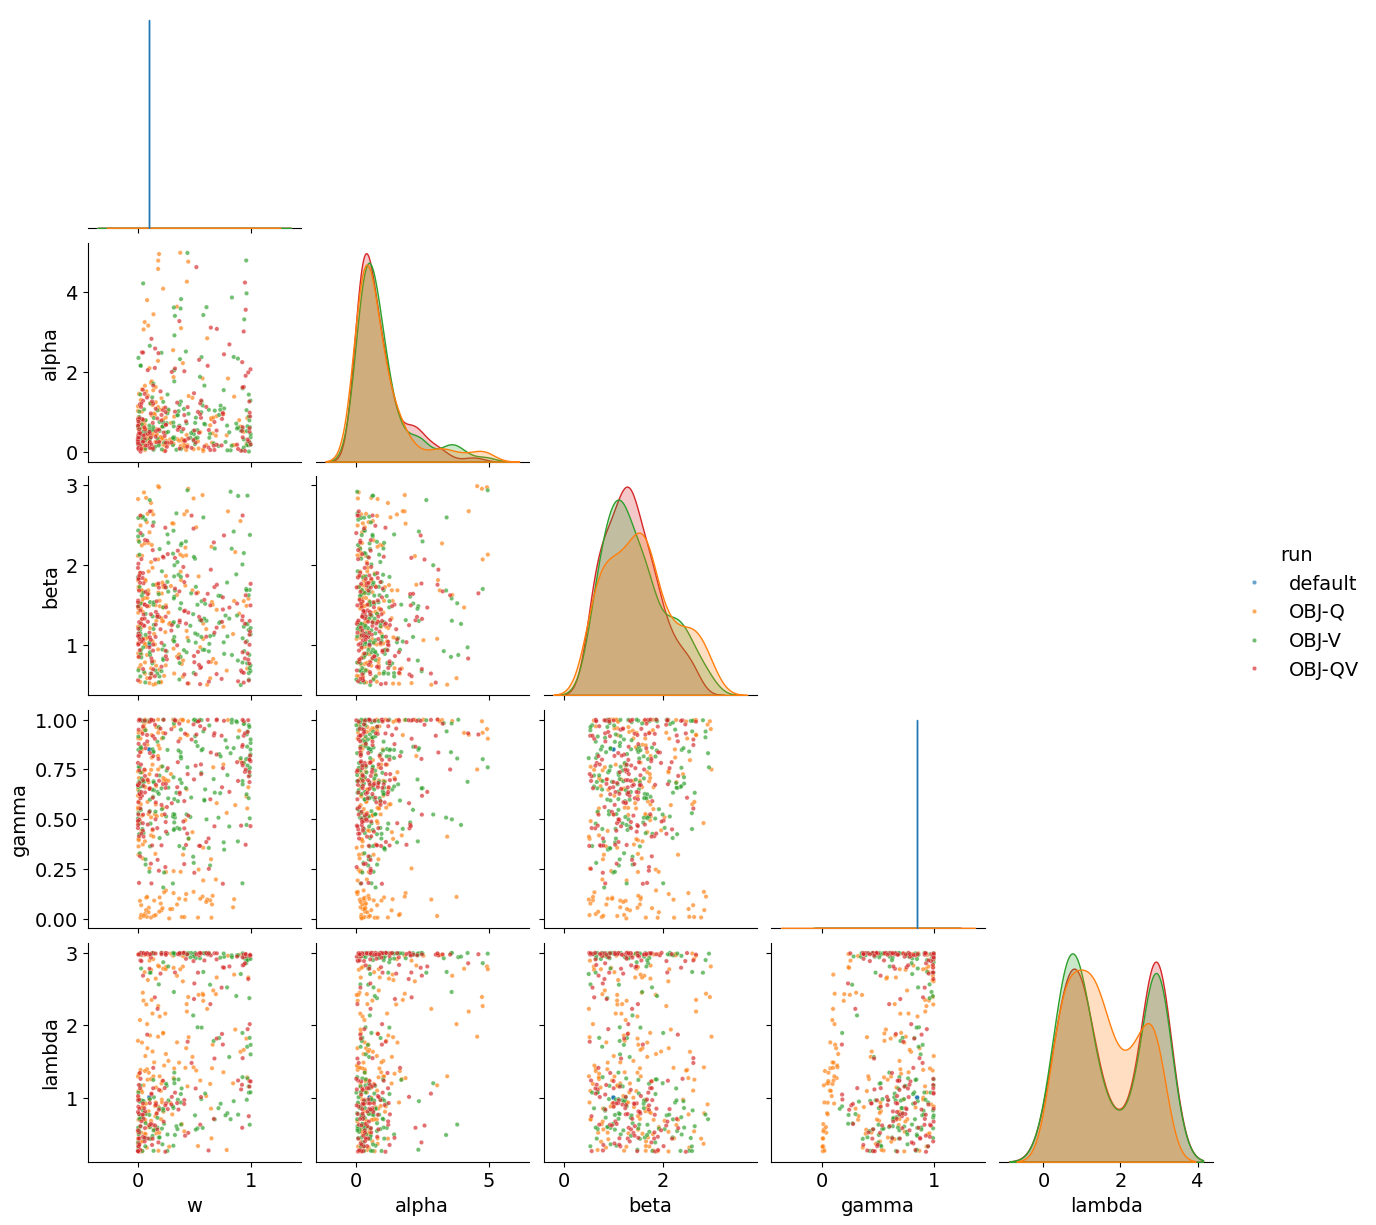

In [32]:
model = 'mhm'

parameter_range = {
    'w': [0.0, 1.0],
    'alpha': [0.0, 5.0],
    'beta': [0.5, 3.0],
    'gamma': [0.0, 1.0],
    'lambda': [0.25, 3.0]
}

if model in models:
    pars_model = parameters[model][list(parameter_range)]

    # boxplot comparing parameterizations across calibration runs
    boxplot_parameters(
        pars_model, 
        parameter_range, 
        save=PATH_RESULTS / model / 'parameters_boxplot.jpg'
    )

    # pairplot comparing parameters
    if len(pars_model) > 1:
        pairplot = sns.pairplot(
            data=pars_model.to_dataframe().reset_index(),
            vars=list(parameter_range),
            hue='run',
            # palette='magma',
            corner=True,
            dropna=True,
            plot_kws={'alpha': 0.666, 's': 10},
        );
        plt.savefig(PATH_RESULTS / model / 'parameters_pairplot.jpg', dpi=300, bbox_inches='tight')

    # # pairplot comparing runs for each parameter
    # for parname, da in pars_model.items():
    #     data = da.to_pandas().transpose()
    #     pairplot= sns.pairplot(data=data,
    #                            # diag_kind='hist',
    #                            # hue='MAIN_USE', 
    #                            corner=True);
    #     pmin, pmax = parameter_range[parname]
    #     pmin -= 2e-2
    #     pmax += 2e-2
    #     for ax in pairplot.axes.flatten():
    #         if ax is None:
    #             continue
    #         ax.set(xlim=(pmin, pmax),
    #                ylim=(pmin, pmax))
    #     pairplot.fig.suptitle(parname, y=.95);
    #     plt.savefig(PATH_RESULTS / model / f'parameter_{parname}_pairplot.jpg', dpi=300, bbox_inches='tight')